#  Análisis Exploratorio de la Calidad del Vino


## 1. Introducción y planteamiento del problema


La calidad del vino es el resultado de múltiples factores fisicoquímicos que influyen directamente en sus propiedades sensoriales, tales como el sabor, el aroma y la textura, así como en la percepción del consumidor. Tradicionalmente, la evaluación de esta calidad ha sido realizada por expertos mediante catas, un proceso que, aunque efectivo, puede presentar cierto grado de subjetividad y limitaciones en términos de estandarización.


En este contexto, el análisis de datos y las técnicas de ciencia de datos permiten abordar el estudio de la calidad del vino desde una perspectiva cuantitativa, utilizando variables medibles para comprender y modelar su comportamiento. El uso de bases de datos como *Wine Quality – Vinho Verde* posibilita explorar la relación entre distintas características fisicoquímicas y la calidad percibida del vino.


A partir de lo anterior, surge la siguiente pregunta de investigación:


**¿Qué variables permiten predecir de mejor manera la calidad del vino?**

---


In [25]:
# Librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url_red = 'https://raw.githubusercontent.com/caamilo03/wine-quality/main/datos/winequality-red.csv'
url_white = 'https://raw.githubusercontent.com/caamilo03/wine-quality/main/datos/winequality-white.csv'

df_red = pd.read_csv(url_red, sep=';')
df_white = pd.read_csv(url_white, sep=';')

df_red.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [26]:
df_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [27]:
# Número de registros y variables
print("== Vino rojo ==")
print(f"Número de registros: {df_red.shape[0]}")
print(f"Número de variables: {df_red.shape[1]}")
print("")

print("== Vino blanco ==")
print(f"Número de registros: {df_white.shape[0]}")
print(f"Número de variables: {df_white.shape[1]}")

== Vino rojo ==
Número de registros: 1599
Número de variables: 12

== Vino blanco ==
Número de registros: 4898
Número de variables: 12


In [28]:
# Tipos de datos
print("\nTipos de datos por variable:")
print(df_red.dtypes.value_counts())
print(df_red.dtypes.value_counts())


Tipos de datos por variable:
float64    11
int64       1
Name: count, dtype: int64
float64    11
int64       1
Name: count, dtype: int64


In [29]:
# Clasificación de variables
categoricas = df_red.select_dtypes(include=['object']).columns.tolist()
numericas = df_red.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(" == Variables categóricas ==")
print("\n".join([f"- {col}" for col in categoricas]))

print("\n == Variables numéricas ==")
print("\n".join([f"- {col}" for col in numericas]))

 == Variables categóricas ==


 == Variables numéricas ==
- fixed acidity
- volatile acidity
- citric acid
- residual sugar
- chlorides
- free sulfur dioxide
- total sulfur dioxide
- density
- pH
- sulphates
- alcohol
- quality


## 2. Descripción de la Base de Datos

Este proyecto utiliza el conjunto de datos **Wine Quality**, el cual está dividido en dos archivos principales correspondientes a variantes del vino portugués "Vinho Verde":
* `winequality-red.csv`: Datos de muestras de vino tinto.
* `winequality-white.csv`: Datos de muestras de vino blanco

- **Total de registros:** 6,497 observaciones
- **Total de variables:** 12 características

Cada registro representa una muestra de vino, acompañada de distintas mediciones fisicoquímicas y su respectiva evaluación de calidad.


In [30]:
# Número de registros y variables
print("== Vino rojo ==")
print(f"Número de registros: {df_red.shape[0]}")
print(f"Número de variables: {df_red.shape[1]}")
print("")

print("== Vino blanco ==")
print(f"Número de registros: {df_white.shape[0]}")
print(f"Número de variables: {df_white.shape[1]}")

== Vino rojo ==
Número de registros: 1599
Número de variables: 12

== Vino blanco ==
Número de registros: 4898
Número de variables: 12


#3. Descripción de las variables


### 3.1 Variables continuas
- `fixed acidity`
- `volatile acidity`
- `citric acid`
- `residual sugar`
- `chlorides`
- `free sulfur dioxide`
- `total sulfur dioxide`
- `density`
- `pH`
- `sulphates`
- `alcohol`


Estas variables corresponden a propiedades químicas y físicas del vino que pueden influir directamente en su sabor, aroma y estabilidad.


### 3.2 Variables categóricas
- `quality`
- `color`


In [31]:
# Tipos de datos
print("\nTipos de datos por variable:")
print(df_red.dtypes.value_counts())


Tipos de datos por variable:
float64    11
int64       1
Name: count, dtype: int64


In [32]:
# Tipos de datos
print("\nTipos de datos por variable:")
print(df_white.dtypes.value_counts())
print(df_white.dtypes.value_counts())


Tipos de datos por variable:
float64    11
int64       1
Name: count, dtype: int64
float64    11
int64       1
Name: count, dtype: int64


# 4. Variable de interés
La variable central de esta investigación es **`quality`**, la cual representa la **calidad del vino**, evaluada a partir de criterios sensoriales.


El objetivo del estudio se centra en **analizar la relación entre la calidad del vino y el resto de las variables**, con el fin de identificar cuáles de ellas ejercen una mayor influencia y poseen un mayor poder predictivo sobre dicha calidad.




#5. Visualizaciones exploratorias básicas

En esta sección se presentan distintas visualizaciones exploratorias con el fin de identificar patrones, relaciones y comportamientos relevantes entre las variables del conjunto de datos, así como su relación con la calidad del vino.


## 5.1 Grafico de barras: Tipo de vino
Este gráfico muestra la distribución de las muestras según el tipo de vino (tinto y blanco), permitiendo identificar la proporción de cada categoría dentro del conjunto de datos.

In [33]:

# Combinar ambos datasets agregando columna 'tipo_vino'
df_red_copy = df_red.copy()
df_white_copy = df_white.copy()

df_red_copy['tipo_vino'] = 'Tinto'
df_white_copy['tipo_vino'] = 'Blanco'

df_vinos = pd.concat([df_red_copy, df_white_copy], ignore_index=True)
print(f"Dataset combinado: {df_vinos.shape[0]} registros, {df_vinos.shape[1]} variables")
df_vinos['tipo_vino'].value_counts()


Dataset combinado: 6497 registros, 13 variables


tipo_vino
Blanco    4898
Tinto     1599
Name: count, dtype: int64

C:\Users\Camilo\AppData\Local\Temp\ipykernel_29196\3152569866.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


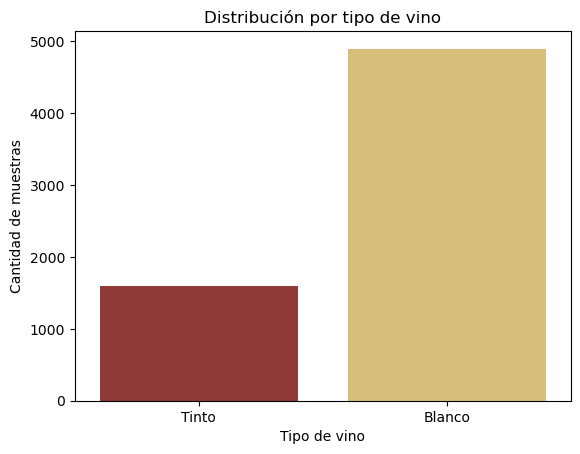

In [34]:
sns.countplot(
    data=df_vinos,
    x='tipo_vino',
    palette=['#9e2a2b', '#e9c46a']  # Tinto / Blanco
)

plt.title("Distribución por tipo de vino")
plt.xlabel("Tipo de vino")
plt.ylabel("Cantidad de muestras")
plt.show()

##5.2  Histogramas
Los histogramas se utilizan para analizar la distribución de las variables numéricas, permitiendo visualizar la concentración de los datos, su dispersión y la presencia de sesgos.

En particular, el histograma de la variable `quality` permite identificar los niveles de calidad más frecuentes y comparar la distribución entre vinos tintos y blancos.


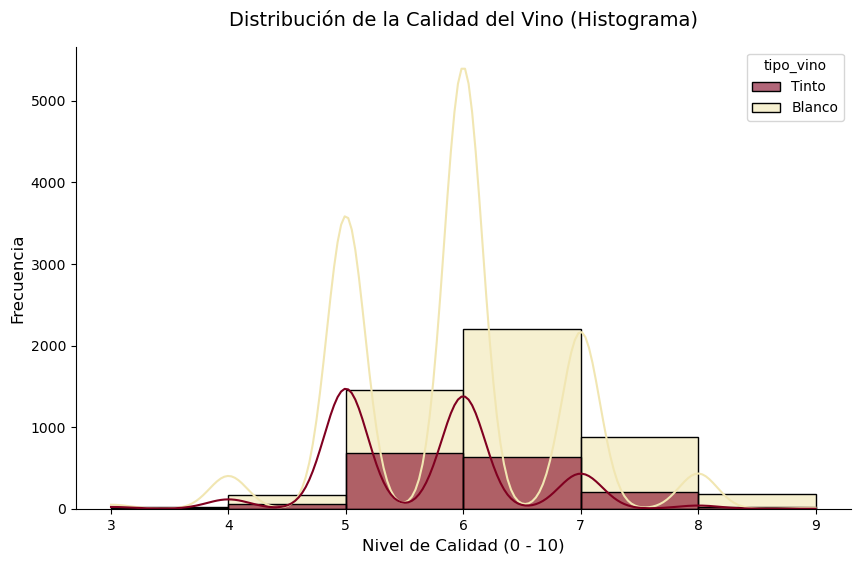

In [35]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_vinos,
    x='quality',
    hue='tipo_vino',
    bins=6,
    kde=True,
    multiple='layer',
    palette={'Tinto': '#800020', 'Blanco': '#f1e6b2'},
    alpha=0.6
)

plt.title('Distribución de la Calidad del Vino (Histograma)', fontsize=14, pad=15)
plt.xlabel('Nivel de Calidad (0 - 10)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

sns.despine()
plt.show()

##5.3 Gráficos de barras
Los gráficos de barras son empleados para representar la frecuencia de variables categóricas o discretas, como los niveles de calidad del vino.

Este tipo de visualización facilita la comparación directa entre categorías, permitiendo observar diferencias en la cantidad de muestras según el tipo de vino y su nivel de calidad.


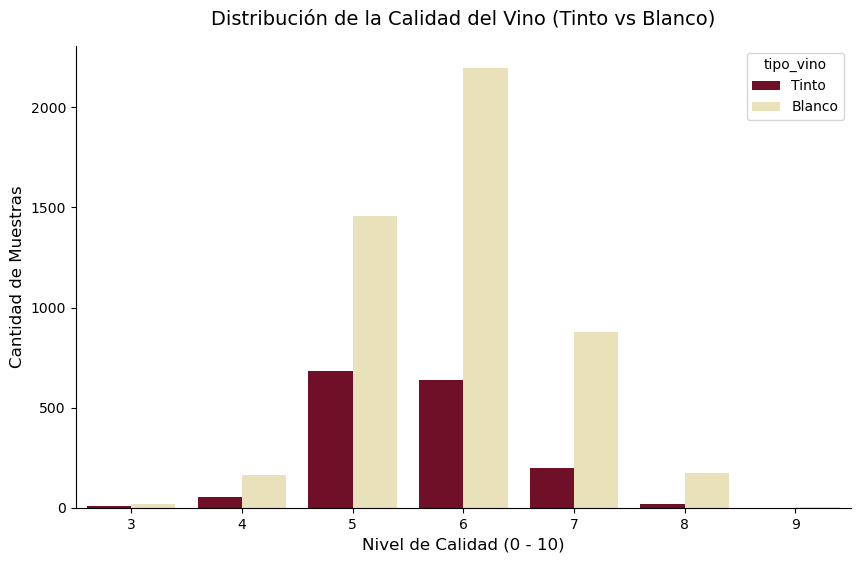

In [36]:
df_red['tipo_vino'] = 'Tinto'
df_white['tipo_vino'] = 'Blanco'

df_vinos = pd.concat([df_red, df_white], ignore_index=True)
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_vinos,
    x='quality',
    hue='tipo_vino',
    palette={'Tinto': '#800020', 'Blanco': '#f1e6b2'}
)


plt.title('Distribución de la Calidad del Vino (Tinto vs Blanco)', fontsize=14, pad=15)
plt.xlabel('Nivel de Calidad (0 - 10)', fontsize=12)
plt.ylabel('Cantidad de Muestras', fontsize=12)


sns.despine()

plt.show()

# 5.4 Grafico de dispersion con linea de tendencia  

Este gráfico de dispersión muestra la relación entre el contenido de alcohol y la concentración de sulfatos en las muestras de vino, diferenciando los niveles de calidad mediante el uso del color, lo que permite observar posibles patrones asociados a la calidad del vino.

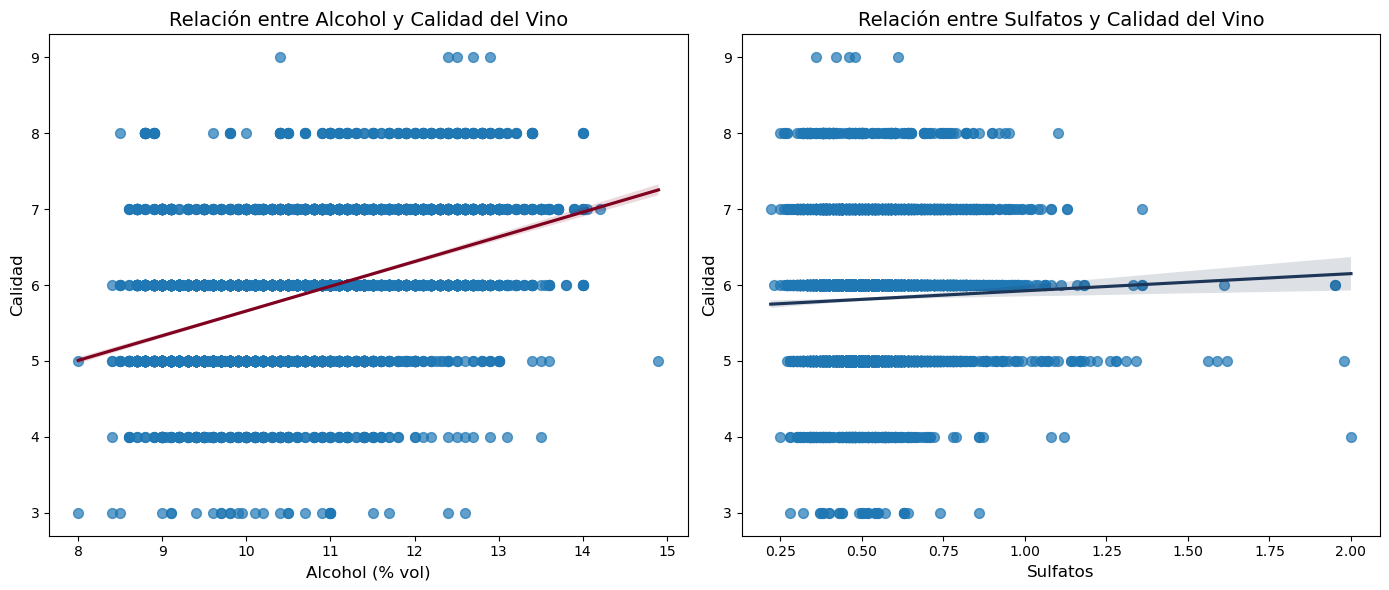

In [37]:
# Gráficos de dispersión con líneas de tendencia
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Alcohol vs Quality
sns.regplot(
    x='alcohol',
    y='quality',
    data=df_vinos,
    ax=axes[0],
    scatter_kws={'s': 50, 'alpha': 0.7},
    line_kws={'color': '#800020'}
)

axes[0].set_title('Relación entre Alcohol y Calidad del Vino', fontsize=14)
axes[0].set_xlabel('Alcohol (% vol)', fontsize=12)
axes[0].set_ylabel('Calidad', fontsize=12)

# Sulphates vs Quality
sns.regplot(
    x='sulphates',
    y='quality',
    data=df_vinos,
    ax=axes[1],
    scatter_kws={'s': 50, 'alpha': 0.7},
    line_kws={'color': '#1d3557'}
)

axes[1].set_title('Relación entre Sulfatos y Calidad del Vino', fontsize=14)
axes[1].set_xlabel('Sulfatos', fontsize=12)
axes[1].set_ylabel('Calidad', fontsize=12)

plt.tight_layout()
plt.show()

## 6. Interpretaciones iniciales

##6.1 ¿Qué tendencias o patrones básicos se observan?

- La variable **calidad del vino (`quality`)** se concentra principalmente en valores intermedios, lo que indica que la mayoría de las muestras corresponden a vinos de calidad media.
- El **vino blanco** presenta más observaciones que el vino tinto, lo que evidencia un desequilibrio en el conjunto de datos.
- Se observa una **relación positiva entre el contenido de alcohol y la calidad del vino**, donde mayores niveles de alcohol tienden a asociarse con calificaciones más altas.
- Variables como los **sulfatos** presentan asociaciones moderadas con la calidad, contribuyendo al perfil sensorial del vino.

---

##6.2 ¿Qué limitaciones tiene la base de datos?

- La variable **`quality`** se basa en evaluaciones sensoriales humanas, lo que introduce un grado de subjetividad en la medición.
- Existe un **desbalance entre vinos tintos y blancos**, lo que puede influir en algunos análisis comparativos.
- La variable de calidad es **categórica u ordinal**, pero a menudo se trata como numérica, lo que requiere precaución en la interpretación de los resultados.

---

##6.3 ¿Qué hipótesis iniciales podrían plantearse para análisis posteriores?

- Un mayor contenido de **alcohol** se asocia con una mayor calidad del vino.
- Existen **diferencias significativas en la calidad** entre vinos tintos y blancos.
- La combinación de múltiples variables fisicoquímicas permite **predecir la calidad del vino** con mayor precisión que el análisis individual de cada variable.

## 7. Conclusiones
- A partir del análisis exploratorio, se identificó con ayuda de la gráfica de histograma, que la **calidad del vino (`quality`)** se concentra en valores intermedios, esto lo indica el comportamiento de la línea KDE (Kernel Density Estimation) y nos dice que el conjunto de datos está compuesto principalmente por vinos de calidad media.
- Las gráficas permitieron evidenciar algunos **patrones entre variables fisicoquímicas y la calidad del vino**, destacándose una relación positiva entre el contenido de alcohol y la calidad.
- El análisis comparativo con gráfico de barras, mostró un **desbalance en la cantidad de muestras entre vinos tintos y blancos**, aspecto que debe considerarse en etapas posteriores del análisis dado que puede prestarse a dar malas interpretaciones.


## 8. Referencias

### Fuente de los datos

- **Dataset:** Wine Quality – Vinho Verde (Portugal)  
- **Repositorio:** : [UCI Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality)
- **Autores:** Paulo Cortez, A. Cerdeira, F. Almeida, T. Matos, J. Reis  
- **Descripción:** Conjunto de datos que contiene mediciones fisicoquímicas de vinos tintos y blancos portugueses de la región Vinho Verde, junto con evaluaciones sensoriales de su calidad. El dataset es ampliamente utilizado en estudios de análisis exploratorio y modelación predictiva en ciencia de datos.